In [1]:
from src.utils.DataFolder import DataFolder
from src.Signal import Signal, ThetaSignal
from src.utils.helper import load_config
from src.pipeline import emd_analysis, get_periods

import numpy as np
import pandas as pd

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

### Loading the arguments

In [2]:
args = load_config(config_path)

fs = args.pop("fs", 2500)
f_theta = (args.pop("f_theta_lower", 4), args.pop("f_theta_upper", 12))
f_lowpass = args.pop("f_lowpass", 25)
n_seconds_filter = args.pop("n_seconds_filter", 0.5)
n_seconds_theta = args.pop("n_seconds_theta", 0.75)

threshold_kwargs = args.pop("threshold_kwargs", None)

n_skip = args.pop("n_skip", 1.0)

In [3]:
remFolder = DataFolder(data_path)
print(remFolder)

DataFolder in '/home/miranjo/phasic_tonic/data/processed', contains 102 files.


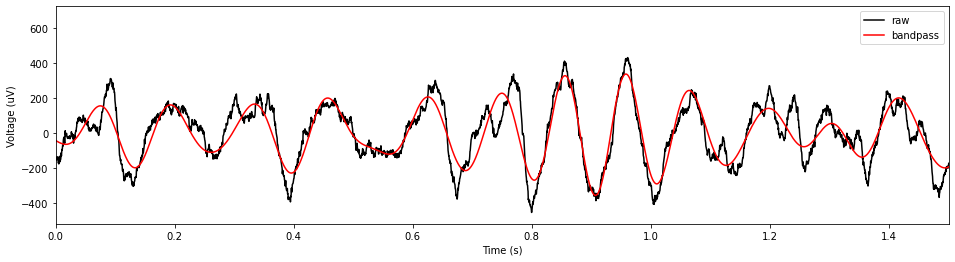

In [4]:
sample = remFolder[3]
lfpREM = sample["data"][0]
metadata = sample["metadata"]

sig = Signal(lfpREM, fs)
sig.filter('bandpass', f_theta, n_seconds_theta)
sig.plot(xlim=(0, 1.5))

In [15]:
from bycycle.features import compute_features


def pipeline(thetaSignal, phasic=True):
    
    df = compute_features(thetaSignal.filtered, thetaSignal.sampling_rate, f_range=f_theta, threshold_kwargs=threshold_kwargs, center_extrema='peak')
    result_msg = "{} periods in the {} signal: {}"

    if(phasic):
        df = df[df['is_burst']]
        print(result_msg.format("Phasic", thetaSignal.filter_type, len(df)))
        if(len(df) == 0):
            print("No phasic periods detected")
            return None
    else:
        df = df[df['is_burst' ] == False]
        print(result_msg.format("Tonic", thetaSignal.filter_type, len(df)))
        if(len(df) == 0):
            print("No tonic periods detected")
            return None

    timestamps = df[["sample_last_trough", "sample_next_trough"]]
    
    skip_threshold = int(n_skip * thetaSignal.sampling_rate)
    periods = get_periods(timestamps, skip_threshold=skip_threshold)
    print("Periods: \n", periods)
    
    segments = []
    for period in periods:
        start, end = period
        segments.append(thetaSignal.filtered[start:end])
    
    print("Length: \n", [len(p) for p in segments])
    
    extracted_dfs = []
    for segment in segments:
        extracted_dfs.append(emd_analysis(segment, thetaSignal.sampling_rate))
    
    return extracted_dfs

tonics = pipeline(sig, phasic=False)

Tonic periods in the bandpass signal: 865
Periods: 
 [(333, 125289), (127831, 171562), (174662, 267133), (269655, 269888), (272945, 305444)]
Length: 
 [124956, 43731, 92471, 233, 32499]
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (380 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
349
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (136 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
123
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (265 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
246
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (2 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
0
Detected cycles before extraction:
<class 'emd.cycles.Cycles'> (94 cycles 1 metrics) 

Finished computing the cycles metrics

Cycles after extraction:
81


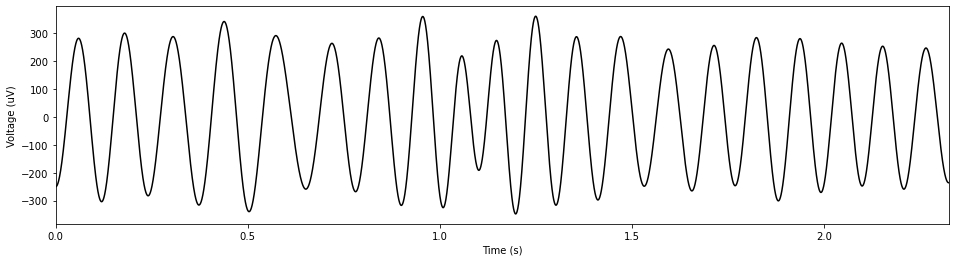

In [19]:
s=Signal(phs[3], fs).plot()


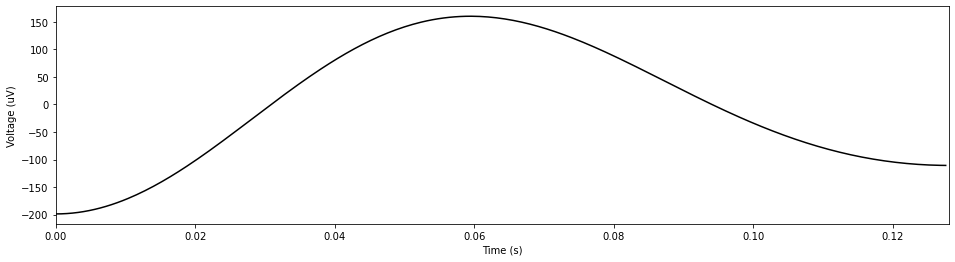

In [20]:
# Trough to Trough 
single = Signal(sig.filtered[333:653], 2500)
single.plot()

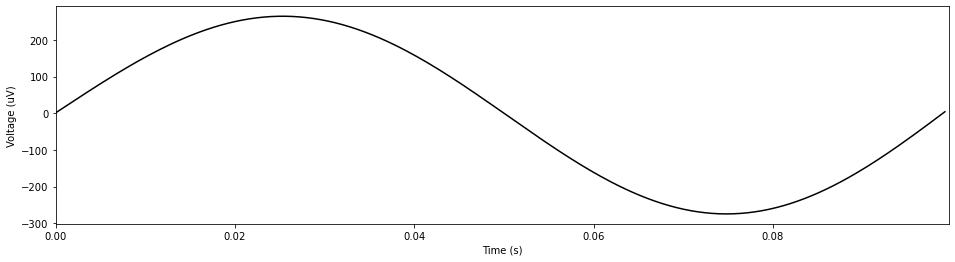

In [21]:
# zero crossing rise to rise
single = Signal(sig.filtered[106835:107084], 2500)
single.plot()

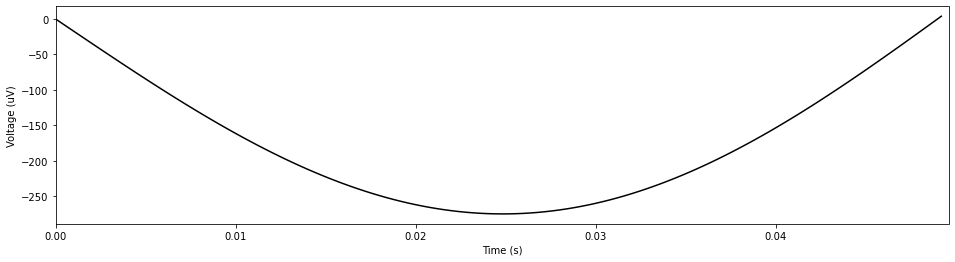

In [22]:
# zero crossing decay to rise
single = Signal(sig.filtered[106960:107084], 2500)
single.plot()